In [1]:

from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:

X,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)
     

df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})

In [3]:
df.head()

,feature1,feature2,target
0,-0.340765,-2.026709,-49.301393
1,-2.096289,-0.998304,-28.275216
2,-0.256515,-1.812981,-25.952174
3,-0.786771,1.131182,38.978884
4,-0.919630,0.368660,-90.173800


In [4]:
df.shape


(100, 3)

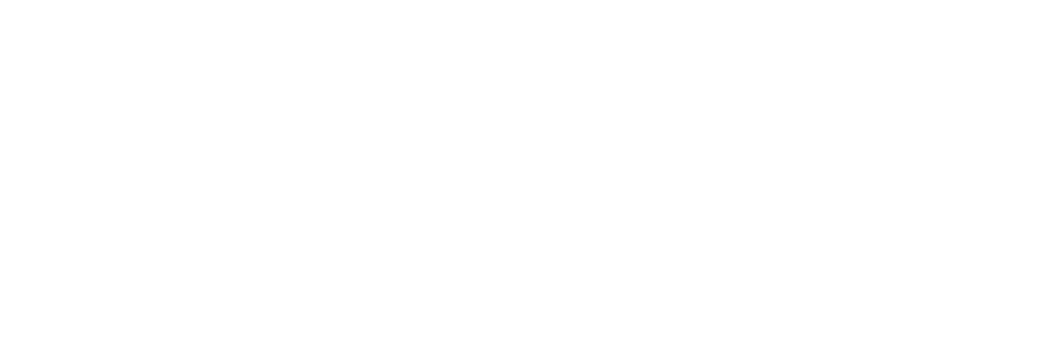

In [5]:
fig = px.scatter_3d(df, x = 'feature1', y = 'feature2', z = 'target')
fig.show()



In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)
     

In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
lr = LinearRegression()

In [10]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
y_pred = lr.predict(X_test)

In [13]:
print('MAE', mean_absolute_error(y_test, y_pred))
print('MSE', mean_squared_error(y_test, y_pred))
print('r2', r2_score(y_test, y_pred))

MAE 45.39292309145756
MSE 3324.7741592082093
r2 0.4711683911930875


In [15]:

x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(y, x)
final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

z = z_final

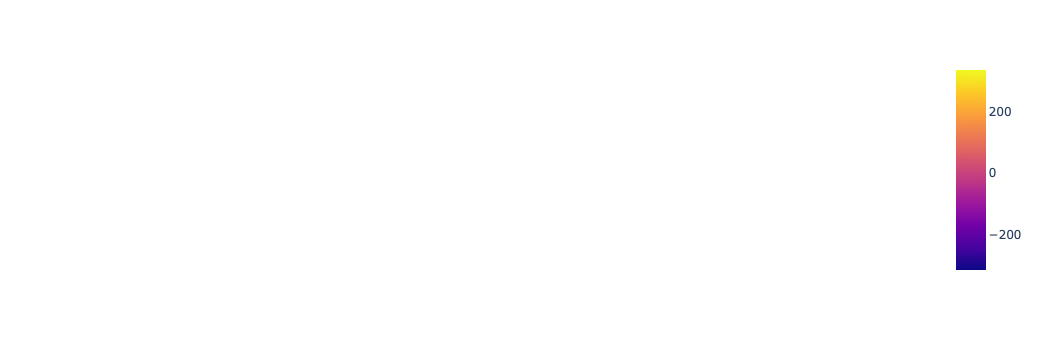

In [16]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

fig.show()

In [21]:
lr.coef_

array([36.10315543, 28.86752639])

In [ ]:
lr.intercept_

In [22]:
lr.intercept_

np.float64(8.907373302505098)